<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Red_Neuronal_MLP_Digitos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

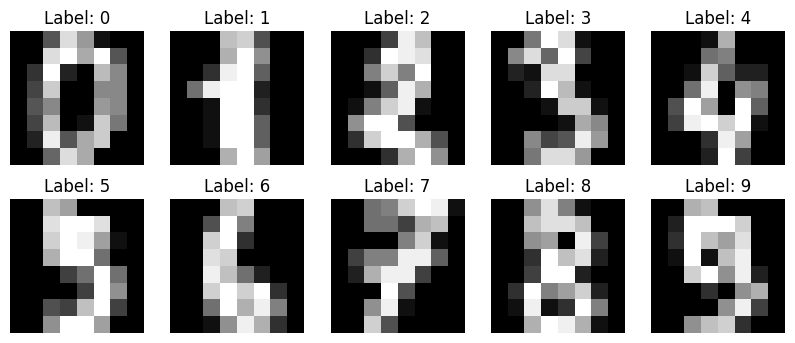

Iteration 1, loss = 2.39014446
Iteration 2, loss = 2.04694924
Iteration 3, loss = 1.76446049
Iteration 4, loss = 1.49766926
Iteration 5, loss = 1.24852846
Iteration 6, loss = 1.02610439
Iteration 7, loss = 0.83784432
Iteration 8, loss = 0.68490346
Iteration 9, loss = 0.56555302
Iteration 10, loss = 0.47269019
Iteration 11, loss = 0.39978805
Iteration 12, loss = 0.34307285
Iteration 13, loss = 0.29883049
Iteration 14, loss = 0.26216946
Iteration 15, loss = 0.23334984
Iteration 16, loss = 0.20901164
Iteration 17, loss = 0.18857971
Iteration 18, loss = 0.17128499
Iteration 19, loss = 0.15629451
Iteration 20, loss = 0.14316985
Iteration 21, loss = 0.13181079
Iteration 22, loss = 0.12115363
Iteration 23, loss = 0.11274056
Iteration 24, loss = 0.10456942
Iteration 25, loss = 0.09706297
Iteration 26, loss = 0.09119109
Iteration 27, loss = 0.08441270
Iteration 28, loss = 0.07879478
Iteration 29, loss = 0.07363559
Iteration 30, loss = 0.06917809
Iteration 31, loss = 0.06497518
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


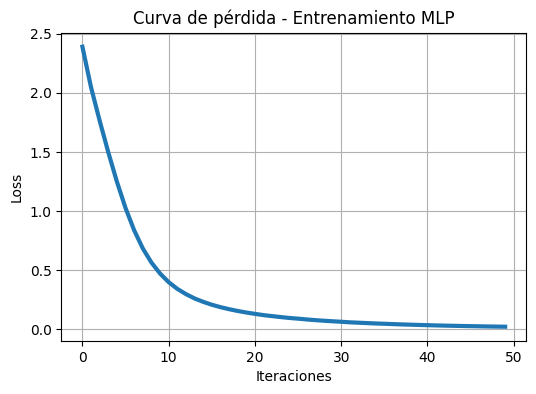

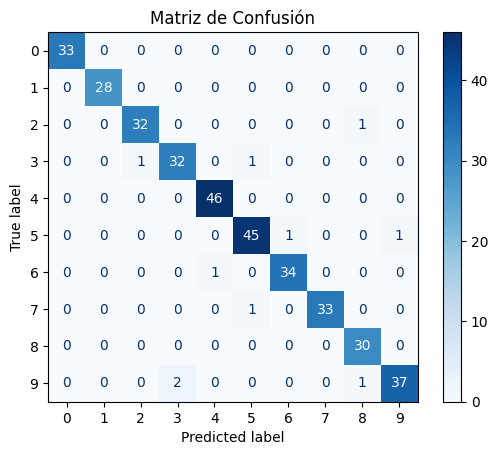

Accuracy: 0.9722222222222222


In [1]:
# Red Neuronal MLP con sklearn - Dataset DIGITS
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cargar dataset
digits = load_digits()
X, y = digits.data, digits.target

# Visualizar muestras
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.show()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Configuración MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    verbose=True
)

# Entrenamiento
mlp.fit(X_train, y_train)

# Gráfica de pérdida
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_, linewidth=3)
plt.title("Curva de pérdida - Entrenamiento MLP")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Evaluación
y_pred = mlp.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

print("Accuracy:", mlp.score(X_test, y_test))
